# Random action agent

Current storage capacity:
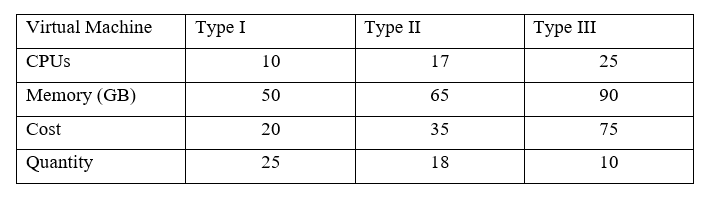

In [1]:
import pprint
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env

import warnings
warnings.filterwarnings("ignore")

In [6]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 1
VM_TYPE1 = 3
VM_TYPE2 = 2
VM_TYPE3 = 1
STEPS = 10
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          alpha = ALPHA,
          beta = BETA)

Check if my custom enivorment correctly follow OpenAI Gym structure

In [3]:
#check_env(env, warn=0, skip_render_check=1)

In [3]:
def run_episode(print_info=False):
    state = env.reset()
    done = False
    score = 0 
    while not done:
        action = env.action_space.sample()
        n_state, reward, done, info = env.step(action)
        
        if print_info:
            pp = pprint.PrettyPrinter(indent=5)
            print("Action: ", action)
            print("Reward: ", reward)
            print("Next state: ", n_state)
            pp.pprint(info)
            print("-----------------------------------------")
        
        score+=reward
    return score

Run single episode and look up detailed information step by step

In [5]:
run_episode(print_info=True)

Action:  3
Reward:  0.08
Next state:  [81.665]
{    'Current cost': 143.33,
     'Quality of Service': 0.1884,
     'Queue len:': 11,
     'Timer': 2.0723893642425537,
     'VM type I': 3,
     'VM type II': 2,
     'VM type III': 4}
-----------------------------------------
Action:  5
Reward:  0.12
Next state:  [116.6675]
{    'Current cost': 131.67,
     'Quality of Service': 0.1877,
     'Queue len:': 11,
     'Timer': 2.0648694038391113,
     'VM type I': 3,
     'VM type II': 1,
     'VM type III': 4}
-----------------------------------------
Action:  2
Reward:  0.13
Next state:  [129.99875]
{    'Current cost': 143.33,
     'Quality of Service': 2.1692,
     'Queue len:': 14,
     'Timer': 30.369329690933228,
     'VM type I': 3,
     'VM type II': 2,
     'VM type III': 4}
-----------------------------------------
Action:  1
Reward:  0.15
Next state:  [149.99937]
{    'Current cost': 150.0,
     'Quality of Service': 0.2141,
     'Queue len:': 10,
     'Timer': 2.140989303588867

1.12

Run 10 episodes (with no detailed information)

In [2]:
scores = []
episodes = []

for episode in range(1, TEST_EPISODES+1):
    score = run_episode(print_info=False)
    scores.append(score)
    episodes.append(episode)
    print('Episode:{} Score:{}'.format(episode, score))

NameError: name 'TEST_EPISODES' is not defined

Vizualize performce on sample episode

In [7]:
obs = env.reset()
culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []

while True:
    action = env.action_space.sample()
    obs, rewards, done, info = env.step(action)
    
    # save the resuls
    culumative_reward+=rewards
    step +=1
    value.append(culumative_reward)
    steps_lst.append(step)
    quality_of_service.append(info['Quality of Service'])
    utility_function.append(obs)
    cost_lst.append(info['Current cost'])
    no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
    queue_len.append(info['Queue len'])
    
    if done: 
        print('info', info)
        break

info {'Quality of Service': 2.5639, 'Current cost': 70.0, 'Queue len': 12, 'Timer': 30.76701855659485, 'VM type I': 5, 'VM type II': 1, 'VM type III': 1}


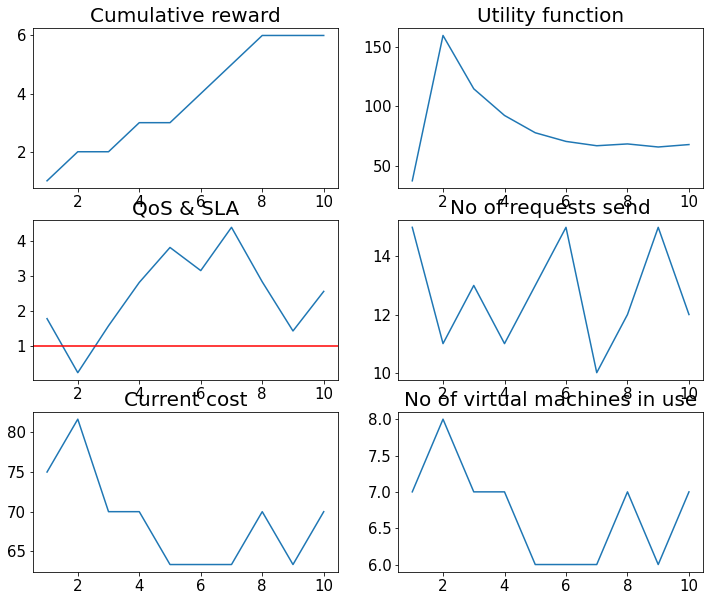

In [8]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)